# Detection experiments

## Импорты, пути и воспроизводимость

In [1]:
import os
import json
import time
import math
import copy
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision.transforms import functional as F
from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn,
    fasterrcnn_mobilenet_v3_large_fpn,
    retinanet_resnet50_fpn,
    FasterRCNN_ResNet50_FPN_Weights,
    FasterRCNN_MobileNet_V3_Large_FPN_Weights,
    RetinaNet_ResNet50_FPN_Weights,
)
from torchvision.ops import box_iou
from torchmetrics.detection.mean_ap import MeanAveragePrecision

import sys
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.data.paths import DATA_PROCESSED_DIR

c:\Users\maxim\OneDrive\Документы\aie_course_rep\aie_course_rep\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Конфигурация экспериментов

In [2]:
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
USE_AMP = DEVICE == "cuda"

IMAGE_SIZE = 512
BATCH_SIZE = 4
NUM_WORKERS = 0 #2 if os.name == "nt" else 4
VAL_SPLIT = 0.2

# Detection models are heavy. Keep epochs moderate for first run.
FAST_MODE = False
FAST_MAX_IMAGES = 1200

EXPERIMENTS_DIR = PROJECT_ROOT / "artifacts" / "vehicle_detection"
FIGURES_DIR = EXPERIMENTS_DIR / "figures"
CHECKPOINTS_DIR = EXPERIMENTS_DIR / "checkpoints"
PREDICTIONS_DIR = EXPERIMENTS_DIR / "predictions"

for p in [EXPERIMENTS_DIR, FIGURES_DIR, CHECKPOINTS_DIR, PREDICTIONS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DEVICE:", DEVICE)
print("USE_AMP:", USE_AMP)
print("DATA_PROCESSED_DIR:", DATA_PROCESSED_DIR)

PROJECT_ROOT: c:\Users\maxim\OneDrive\Документы\aie_course_rep\aie_course_rep\project
DEVICE: cuda
USE_AMP: True
DATA_PROCESSED_DIR: C:\Users\maxim\OneDrive\Документы\aie_course_rep\aie_course_rep\project\data\processed


In [3]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

In [4]:
DET_DIR = DATA_PROCESSED_DIR / "detection"
IMAGES_DIR = DET_DIR / "images"
ANN_CSV = DET_DIR / "annotations.csv"

assert DET_DIR.exists(), f"Не найдена папка: {DET_DIR}"
assert IMAGES_DIR.exists(), f"Не найдена папка с изображениями: {IMAGES_DIR}"
assert ANN_CSV.exists(), f"Не найден файл аннотаций: {ANN_CSV}"


## Загрузка аннотаций

In [5]:
ann_df = pd.read_csv(ANN_CSV)
print("annotations shape:", ann_df.shape)
display(ann_df.head())

annotations shape: (194539, 8)


,image,label,xmin,ymin,xmax,ymax,image_width,image_height
0,1478900859981702684_jpg.rf.6830635c7d919747563...,car,291,247,370,331,512,512
1,1478900859981702684_jpg.rf.6830635c7d919747563...,pedestrian,270,235,293,321,512,512
2,1478900859981702684_jpg.rf.6830635c7d919747563...,car,0,266,13,327,512,512
3,1478900859981702684_jpg.rf.6830635c7d919747563...,car,25,258,106,304,512,512
4,1478900859981702684_jpg.rf.6830635c7d919747563...,car,111,259,135,289,512,512


## Sanity check

In [6]:
required_columns = {"image", "label", "xmin", "ymin", "xmax", "ymax", "image_width", "image_height"}
missing_columns = required_columns - set(ann_df.columns)
if missing_columns:
    raise ValueError(f"В annotations.csv отсутствуют колонки: {missing_columns}")

ann_df = ann_df.copy()
ann_df["label"] = ann_df["label"].astype(str)

print("Unique labels:", sorted(ann_df["label"].unique().tolist())[:20])
print("Num unique labels:", ann_df["label"].nunique())
print("Num images with boxes:", ann_df["image"].nunique())

Unique labels: ['biker', 'car', 'pedestrian', 'trafficLight', 'trafficLight-Green', 'trafficLight-GreenLeft', 'trafficLight-Red', 'trafficLight-RedLeft', 'trafficLight-Yellow', 'trafficLight-YellowLeft', 'truck']
Num unique labels: 11
Num images with boxes: 26300


In [7]:
if FAST_MODE:
    keep_images = ann_df["image"].drop_duplicates().head(FAST_MAX_IMAGES).tolist()
    ann_df = ann_df[ann_df["image"].isin(keep_images)].reset_index(drop=True)
    print("FAST_MODE enabled")
    print("annotations shape:", ann_df.shape)
    print("num images:", ann_df["image"].nunique())

classes = sorted(ann_df["label"].unique().tolist())
label_to_id = {label: i + 1 for i, label in enumerate(classes)}  # 0 reserved for background
id_to_label = {v: k for k, v in label_to_id.items()}
num_classes = len(classes) + 1

print("label_to_id:", label_to_id)
print("num_classes (including background):", num_classes)


label_to_id: {'biker': 1, 'car': 2, 'pedestrian': 3, 'trafficLight': 4, 'trafficLight-Green': 5, 'trafficLight-GreenLeft': 6, 'trafficLight-Red': 7, 'trafficLight-RedLeft': 8, 'trafficLight-Yellow': 9, 'trafficLight-YellowLeft': 10, 'truck': 11}
num_classes (including background): 12


In [8]:
def build_image_records(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for image_name, g in df.groupby("image"):
        rows.append({
            "image": image_name,
            "num_boxes": len(g),
            "labels": g["label"].tolist(),
        })
    return pd.DataFrame(rows)

image_records = build_image_records(ann_df)
print("image_records shape:", image_records.shape)
display(image_records.head())

image_records shape: (26300, 3)


,image,num_boxes,labels
0,1478019952686311006_jpg.rf.54e2d12dbabc46be3c7...,4,"[truck, car, car, pedestrian]"
1,1478019952686311006_jpg.rf.JLSB3LP2Q4RuGHYKqfF...,4,"[truck, car, car, pedestrian]"
2,1478019953180167674_jpg.rf.8a816c9d7e9b423a63e...,4,"[truck, car, truck, car]"
3,1478019953180167674_jpg.rf.azslsZnM8FLQPu3QWLT...,4,"[truck, car, truck, car]"
4,1478019953689774621_jpg.rf.2e4b7ae29c3379da128...,6,"[pedestrian, truck, car, car, car, car]"


## Train/val split

In [9]:
def split_images_by_seed(image_names: List[str], val_ratio: float = 0.2, seed: int = 42):
    image_names = list(image_names)
    rng = np.random.RandomState(seed)
    rng.shuffle(image_names)
    n_val = max(1, int(len(image_names) * val_ratio))
    val_images = set(image_names[:n_val])
    train_images = set(image_names[n_val:])
    return train_images, val_images

train_images, val_images = split_images_by_seed(
    image_records["image"].tolist(),
    val_ratio=VAL_SPLIT,
    seed=SEED,
)

train_df = ann_df[ann_df["image"].isin(train_images)].reset_index(drop=True)
val_df = ann_df[ann_df["image"].isin(val_images)].reset_index(drop=True)

print("train annotations:", len(train_df), "| train images:", train_df["image"].nunique())
print("val annotations:", len(val_df), "| val images:", val_df["image"].nunique())

train annotations: 155377 | train images: 21040
val annotations: 39162 | val images: 5260


# Transforms

In [10]:
class DetectionTrainTransform:
    def __init__(self, image_size: int = 512):
        self.image_size = image_size

    def __call__(self, image: Image.Image, target: Dict):
        w0, h0 = image.size
        image = F.resize(image, [self.image_size, self.image_size])
        scale_x = self.image_size / w0
        scale_y = self.image_size / h0

        boxes = target["boxes"].clone()
        boxes[:, [0, 2]] *= scale_x
        boxes[:, [1, 3]] *= scale_y
        target["boxes"] = boxes

        if random.random() < 0.5:
            image = F.hflip(image)
            boxes = target["boxes"].clone()
            x1 = boxes[:, 0].clone()
            x2 = boxes[:, 2].clone()
            boxes[:, 0] = self.image_size - x2
            boxes[:, 2] = self.image_size - x1
            target["boxes"] = boxes

        image = F.to_tensor(image)
        return image, target


class DetectionValTransform:
    def __init__(self, image_size: int = 512):
        self.image_size = image_size

    def __call__(self, image: Image.Image, target: Dict):
        w0, h0 = image.size
        image = F.resize(image, [self.image_size, self.image_size])
        scale_x = self.image_size / w0
        scale_y = self.image_size / h0

        boxes = target["boxes"].clone()
        boxes[:, [0, 2]] *= scale_x
        boxes[:, [1, 3]] *= scale_y
        target["boxes"] = boxes

        image = F.to_tensor(image)
        return image, target

## Detection Dataset

In [11]:
class DetectionDataset(Dataset):
    def __init__(
        self,
        images_dir: str | Path,
        annotations_df: pd.DataFrame,
        label_to_id: Dict[str, int],
        transform=None,
    ):
        self.images_dir = Path(images_dir)
        self.annotations_df = annotations_df.copy().reset_index(drop=True)
        self.label_to_id = label_to_id
        self.transform = transform
        self.image_names = sorted(self.annotations_df["image"].unique().tolist())

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        image_name = self.image_names[idx]
        rows = self.annotations_df[self.annotations_df["image"].eq(image_name)].reset_index(drop=True)
        image_path = self.images_dir / image_name

        if not image_path.exists():
            raise FileNotFoundError(f"{image_path} not found")

        image = Image.open(image_path).convert("RGB")
        boxes = torch.tensor(rows[["xmin", "ymin", "xmax", "ymax"]].values, dtype=torch.float32)
        labels = torch.tensor([self.label_to_id[x] for x in rows["label"].tolist()], dtype=torch.int64)

        # clean invalid boxes
        widths = boxes[:, 2] - boxes[:, 0]
        heights = boxes[:, 3] - boxes[:, 1]
        valid = (widths > 1) & (heights > 1)
        boxes = boxes[valid]
        labels = labels[valid]

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx], dtype=torch.int64),
            "area": (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1]),
            "iscrowd": torch.zeros((len(boxes),), dtype=torch.int64),
            "image_name": image_name,
        }

        if self.transform is not None:
            image, target = self.transform(image, target)
        else:
            image = F.to_tensor(image)

        return image, target

# Dataloaders

In [12]:
def collate_fn(batch):
    images, targets = zip(*batch)
    return list(images), list(targets)

# %%
train_dataset = DetectionDataset(
    images_dir=IMAGES_DIR,
    annotations_df=train_df,
    label_to_id=label_to_id,
    transform=DetectionTrainTransform(IMAGE_SIZE),
)

val_dataset = DetectionDataset(
    images_dir=IMAGES_DIR,
    annotations_df=val_df,
    label_to_id=label_to_id,
    transform=DetectionValTransform(IMAGE_SIZE),
)

In [13]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE == "cuda"),
    collate_fn=collate_fn,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE == "cuda"),
    collate_fn=collate_fn,
)

print("train batches:", len(train_loader))
print("val batches:", len(val_loader))

train batches: 5260
val batches: 1315


## Визуальная проверка батча

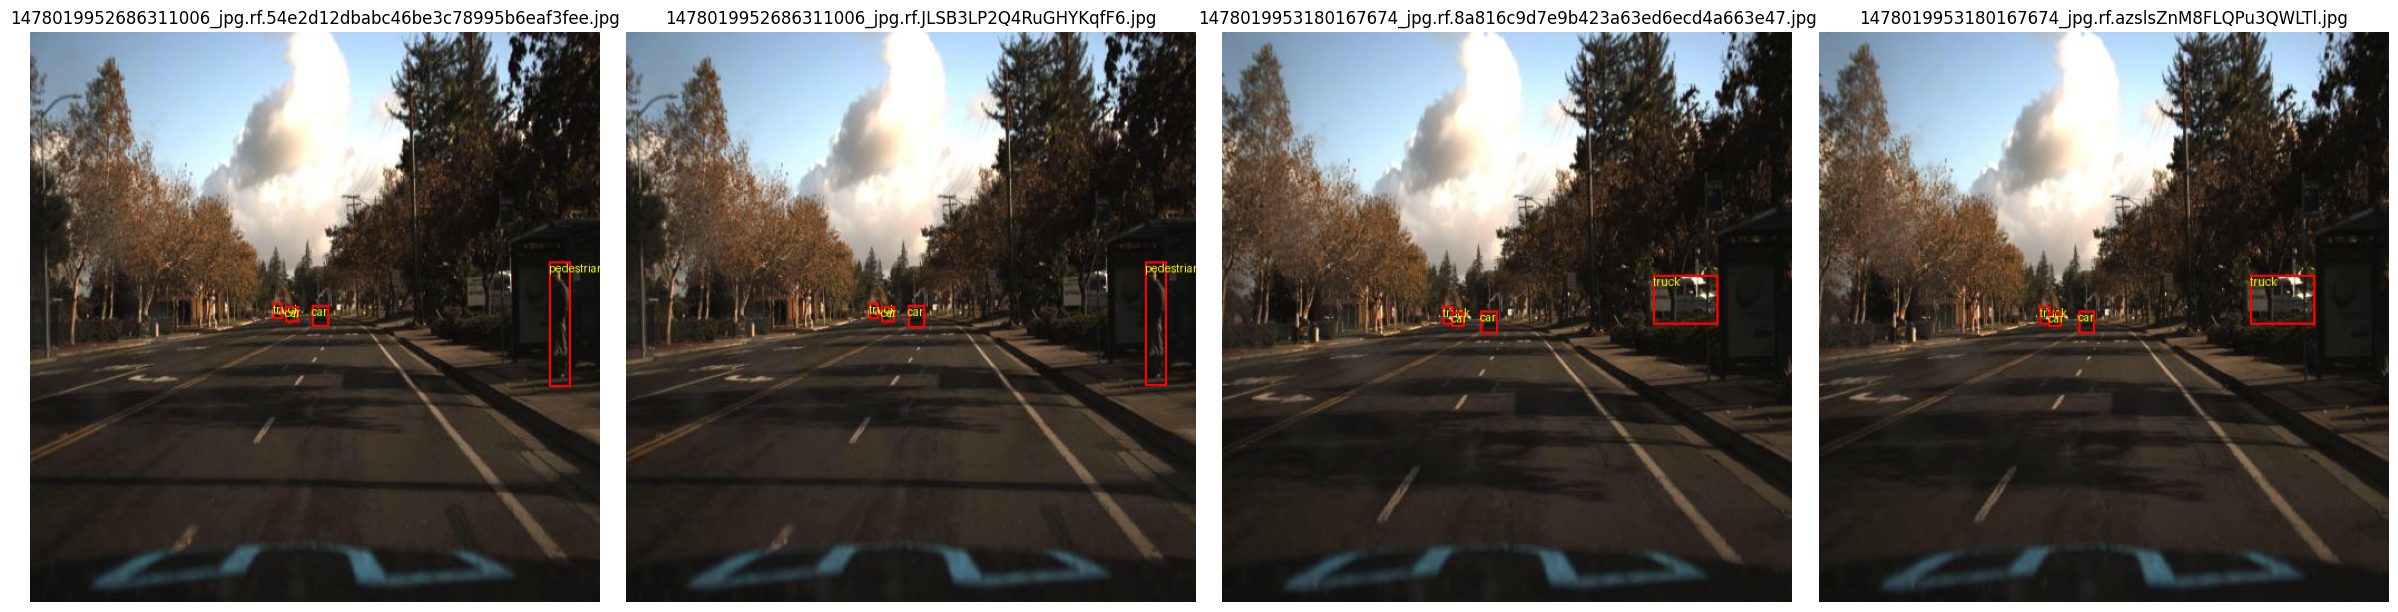

In [14]:
def draw_boxes_on_pil(image: Image.Image, boxes: np.ndarray, labels: List[str] | None = None):
    image = image.copy()
    draw = ImageDraw.Draw(image)
    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = box.tolist()
        draw.rectangle([x1, y1, x2, y2], outline="red", width=2)
        if labels is not None:
            draw.text((x1, y1), str(labels[i]), fill="yellow")
    return image


def show_gt_examples(dataset: DetectionDataset, n: int = 4):
    n = min(n, len(dataset))
    plt.figure(figsize=(6 * n, 6))
    for i in range(n):
        image_name = dataset.image_names[i]
        rows = dataset.annotations_df[dataset.annotations_df["image"].eq(image_name)]
        img = Image.open(dataset.images_dir / image_name).convert("RGB")
        img = draw_boxes_on_pil(
            img,
            rows[["xmin", "ymin", "xmax", "ymax"]].values,
            rows["label"].tolist(),
        )
        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.title(image_name)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_gt_examples(train_dataset, n=4)

## Создание модели

In [15]:
@dataclass
class DetectionExperimentConfig:
    experiment_id: str
    model_name: str
    epochs: int = 6
    lr: float = 1e-4
    weight_decay: float = 1e-4
    patience: int = 2
    score_threshold: float = 0.3

In [16]:
def build_detection_model(model_name: str, num_classes: int):
    model_name = model_name.lower()

    if model_name == "fasterrcnn_resnet50_fpn":
        weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
        model = fasterrcnn_resnet50_fpn(weights=weights)
        in_features = model.roi_heads.box_predictor.cls_score.in_features
        model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)

    elif model_name == "fasterrcnn_mobilenet_v3_large_fpn":
        weights = FasterRCNN_MobileNet_V3_Large_FPN_Weights.DEFAULT
        model = fasterrcnn_mobilenet_v3_large_fpn(weights=weights)
        in_features = model.roi_heads.box_predictor.cls_score.in_features
        model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)

    elif model_name == "retinanet_resnet50_fpn":
        weights = RetinaNet_ResNet50_FPN_Weights.DEFAULT
        model = retinanet_resnet50_fpn(weights=weights)
        num_anchors = model.head.classification_head.num_anchors
        model.head.classification_head.num_classes = num_classes
        model.head.classification_head.cls_logits = nn.Conv2d(
            model.backbone.out_channels,
            num_anchors * num_classes,
            kernel_size=3,
            stride=1,
            padding=1,
        )
        torch.nn.init.normal_(model.head.classification_head.cls_logits.weight, std=0.01)
        torch.nn.init.constant_(model.head.classification_head.cls_logits.bias, 0)

    else:
        raise ValueError(f"Unknown detection model: {model_name}")

    return model

## Расчет основных метрик IoU и matching

In [17]:
def prepare_map_predictions(output, score_threshold=0.3):
    pred_boxes = output["boxes"].detach().cpu()
    pred_scores = output["scores"].detach().cpu()
    pred_labels = output["labels"].detach().cpu()

    keep = pred_scores >= score_threshold
    pred_boxes = pred_boxes[keep]
    pred_scores = pred_scores[keep]
    pred_labels = pred_labels[keep]

    return {
        "boxes": pred_boxes,
        "scores": pred_scores,
        "labels": pred_labels,
    }


def prepare_map_targets(target):
    return {
        "boxes": target["boxes"].detach().cpu(),
        "labels": target["labels"].detach().cpu(),
    }

@torch.no_grad()
def match_predictions_to_targets(pred_boxes, pred_scores, gt_boxes, iou_thr=0.5):
    if len(pred_boxes) == 0 and len(gt_boxes) == 0:
        return 0, 0, 0
    if len(pred_boxes) == 0:
        return 0, 0, len(gt_boxes)
    if len(gt_boxes) == 0:
        return 0, len(pred_boxes), 0

    ious = box_iou(pred_boxes, gt_boxes)
    matched_gt = set()
    tp = 0
    fp = 0

    order = torch.argsort(pred_scores, descending=True)
    for idx in order.tolist():
        iou_row = ious[idx]
        best_iou, best_gt_idx = torch.max(iou_row, dim=0)
        best_gt_idx = int(best_gt_idx.item())
        if best_iou.item() >= iou_thr and best_gt_idx not in matched_gt:
            matched_gt.add(best_gt_idx)
            tp += 1
        else:
            fp += 1

    fn = len(gt_boxes) - len(matched_gt)
    return tp, fp, fn

@torch.no_grad()
def evaluate_detection(model, loader, score_threshold=0.3, iou_thr=0.5):
    model.eval()
    total_tp = 0
    total_fp = 0
    total_fn = 0
    image_stats = []

    for images, targets in loader:
        images = [img.to(DEVICE) for img in images]
        outputs = model(images)

        for output, target in zip(outputs, targets):
            pred_boxes = output["boxes"].detach().cpu()
            pred_scores = output["scores"].detach().cpu()
            pred_labels = output["labels"].detach().cpu()

            keep = pred_scores >= score_threshold
            pred_boxes = pred_boxes[keep]
            pred_scores = pred_scores[keep]
            pred_labels = pred_labels[keep]

            gt_boxes = target["boxes"].detach().cpu()
            gt_labels = target["labels"].detach().cpu()

            # for multi-class detection, match within class
            classes_here = sorted(set(gt_labels.tolist()) | set(pred_labels.tolist()))
            img_tp = img_fp = img_fn = 0
            for cls_id in classes_here:
                pb = pred_boxes[pred_labels == cls_id]
                ps = pred_scores[pred_labels == cls_id]
                gb = gt_boxes[gt_labels == cls_id]
                tp, fp, fn = match_predictions_to_targets(pb, ps, gb, iou_thr=iou_thr)
                img_tp += tp
                img_fp += fp
                img_fn += fn

            total_tp += img_tp
            total_fp += img_fp
            total_fn += img_fn
            image_stats.append({
                "image_name": target["image_name"],
                "tp": img_tp,
                "fp": img_fp,
                "fn": img_fn,
            })

    precision = total_tp / (total_tp + total_fp + 1e-8)
    recall = total_tp / (total_tp + total_fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    return {
        "precision@0.5": precision,
        "recall@0.5": recall,
        "f1@0.5": f1,
        "tp": total_tp,
        "fp": total_fp,
        "fn": total_fn,
        "image_stats": pd.DataFrame(image_stats),
    }

@torch.no_grad()
def evaluate_detection_map(model, loader, score_threshold=0.3):
    model.eval()

    metric = MeanAveragePrecision(
        box_format="xyxy",
        iou_type="bbox",
    )

    for images, targets in loader:
        images = [img.to(DEVICE) for img in images]
        outputs = model(images)

        preds_for_map = []
        targets_for_map = []

        for output, target in zip(outputs, targets):
            preds_for_map.append(
                prepare_map_predictions(output, score_threshold=score_threshold)
            )
            targets_for_map.append(
                prepare_map_targets(target)
            )

        metric.update(preds_for_map, targets_for_map)

    result = metric.compute()

    return {
        "map": float(result["map"].item()),
        "map_50": float(result["map_50"].item()),
        "map_75": float(result["map_75"].item()),
        "mar_1": float(result["mar_1"].item()),
        "mar_10": float(result["mar_10"].item()),
        "mar_100": float(result["mar_100"].item()),
    }

## Обучение модели

In [18]:
def train_one_epoch(model, loader, optimizer, scaler):
    model.train()
    total_loss = 0.0
    total_batches = 0

    loader_lens = [len(loader) // 4, len(loader) // 2, (3 * len(loader)) // 4, len(loader)]

    for batch_idx, (images, targets) in enumerate(loader, start=1):
        images = [img.to(DEVICE, non_blocking=True) for img in images]
        targets_gpu = []
        for t in targets:
            targets_gpu.append({
                "boxes": t["boxes"].to(DEVICE),
                "labels": t["labels"].to(DEVICE),
                "image_id": t["image_id"].to(DEVICE),
                "area": t["area"].to(DEVICE),
                "iscrowd": t["iscrowd"].to(DEVICE),
            })

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type="cuda", enabled=USE_AMP):
            loss_dict = model(images, targets_gpu)
            loss = sum(v for v in loss_dict.values())

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        total_batches += 1

        if batch_idx in loader_lens:
            print(f"Train this epoch - {(batch_idx/len(loader))*100:.1f}%")

    return {"loss": total_loss / max(total_batches, 1)}

def fit_model(model, train_loader, val_loader, optimizer, scheduler, exp_name, epochs, patience, score_threshold):
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
    best_state = None
    best_metric = -1.0
    bad_epochs = 0

    history = {
        "train_loss": [],
        "val_precision": [],
        "val_recall": [],
        "val_f1": [],
        "val_map": [],
        "val_map_50": [],
        "val_map_75": [],
    }

    ckpt_path = CHECKPOINTS_DIR / f"{exp_name}.pt"

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        train_metrics = train_one_epoch(model, train_loader, optimizer, scaler)
        val_metrics = evaluate_detection(model, val_loader, score_threshold=score_threshold, iou_thr=0.5)

        val_map_metrics = evaluate_detection_map(
            model,
            val_loader,
            score_threshold=score_threshold,
        )

        history["train_loss"].append(train_metrics["loss"])
        history["val_precision"].append(val_metrics["precision@0.5"])
        history["val_recall"].append(val_metrics["recall@0.5"])
        history["val_f1"].append(val_metrics["f1@0.5"])
        history["val_map"].append(val_map_metrics["map"])
        history["val_map_50"].append(val_map_metrics["map_50"])
        history["val_map_75"].append(val_map_metrics["map_75"])

        if scheduler is not None:
            scheduler.step(train_metrics["loss"])

        current_metric = val_map_metrics["map_50"]
        min_delta = 1e-4
        if current_metric > best_metric + min_delta:
            best_metric = current_metric
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, ckpt_path)
            bad_epochs = 0
        else:
            bad_epochs += 1

        dt = time.time() - t0
        print(
            f"[{exp_name}] epoch {epoch:02d}/{epochs} | "
            f"train_loss={train_metrics['loss']:.4f} | "
            f"val_precision={val_metrics['precision@0.5']:.4f} "
            f"val_recall={val_metrics['recall@0.5']:.4f} "
            f"val_f1={val_metrics['f1@0.5']:.4f} | "
            f"val_map={val_map_metrics['map']:.4f} "
            f"val_map50={val_map_metrics['map_50']:.4f} "
            f"val_map75={val_map_metrics['map_75']:.4f} | "
            f"time={dt:.1f}s"
        )

        if bad_epochs >= patience:
            print(f"Early stopping for {exp_name} at epoch {epoch}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history, ckpt_path

def plot_history(history: Dict[str, List[float]], title: str, save_path: Path | None = None):
    epochs = range(1, len(history["train_loss"]) + 1)
    plt.figure(figsize=(18, 4))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.title(f"{title} — train loss")
    plt.xlabel("epoch")
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(epochs, history["val_precision"], label="precision@0.5")
    plt.plot(epochs, history["val_recall"], label="recall@0.5")
    plt.plot(epochs, history["val_f1"], label="f1@0.5")
    plt.title(f"{title} — val PR/F1")
    plt.xlabel("epoch")
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(epochs, history["val_map"], label="mAP@0.5:0.95")
    plt.plot(epochs, history["val_map_50"], label="mAP@0.5")
    plt.plot(epochs, history["val_map_75"], label="mAP@0.75")
    plt.title(f"{title} — val mAP")
    plt.xlabel("epoch")
    plt.legend()

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

## План обучения

In [19]:
experiment_plan = [
    DetectionExperimentConfig(
        experiment_id="DET_FR50",
        model_name="fasterrcnn_resnet50_fpn",
        epochs=6,
        lr=1e-4,
        patience=2,
        score_threshold=0.3,
    ),
    DetectionExperimentConfig(
        experiment_id="DET_FMMB",
        model_name="fasterrcnn_mobilenet_v3_large_fpn",
        epochs=6,
        lr=1e-4,
        patience=2,
        score_threshold=0.3,
    ),
    DetectionExperimentConfig(
        experiment_id="DET_RET50",
        model_name="retinanet_resnet50_fpn",
        epochs=6,
        lr=1e-4,
        patience=2,
        score_threshold=0.3,
    ),
]

## Полное обучение моделей


START EXPERIMENT: DET_FR50 | fasterrcnn_resnet50_fpn
Train this epoch - 25.0%
Train this epoch - 50.0%
Train this epoch - 75.0%
Train this epoch - 100.0%
[DET_FR50] epoch 01/6 | train_loss=0.5366 | val_precision=0.5832 val_recall=0.7650 val_f1=0.6618 | val_map=0.2188 val_map50=0.4404 val_map75=0.1884 | time=3185.6s
Train this epoch - 25.0%
Train this epoch - 50.0%
Train this epoch - 75.0%
Train this epoch - 100.0%
[DET_FR50] epoch 02/6 | train_loss=0.4721 | val_precision=0.6132 val_recall=0.7826 val_f1=0.6877 | val_map=0.2540 val_map50=0.5078 val_map75=0.2243 | time=2990.0s
Train this epoch - 25.0%
Train this epoch - 50.0%
Train this epoch - 75.0%
Train this epoch - 100.0%
[DET_FR50] epoch 03/6 | train_loss=0.4387 | val_precision=0.6397 val_recall=0.7985 val_f1=0.7103 | val_map=0.2875 val_map50=0.5745 val_map75=0.2496 | time=2981.0s
Train this epoch - 25.0%
Train this epoch - 50.0%
Train this epoch - 75.0%
Train this epoch - 100.0%
[DET_FR50] epoch 04/6 | train_loss=0.4145 | val_preci

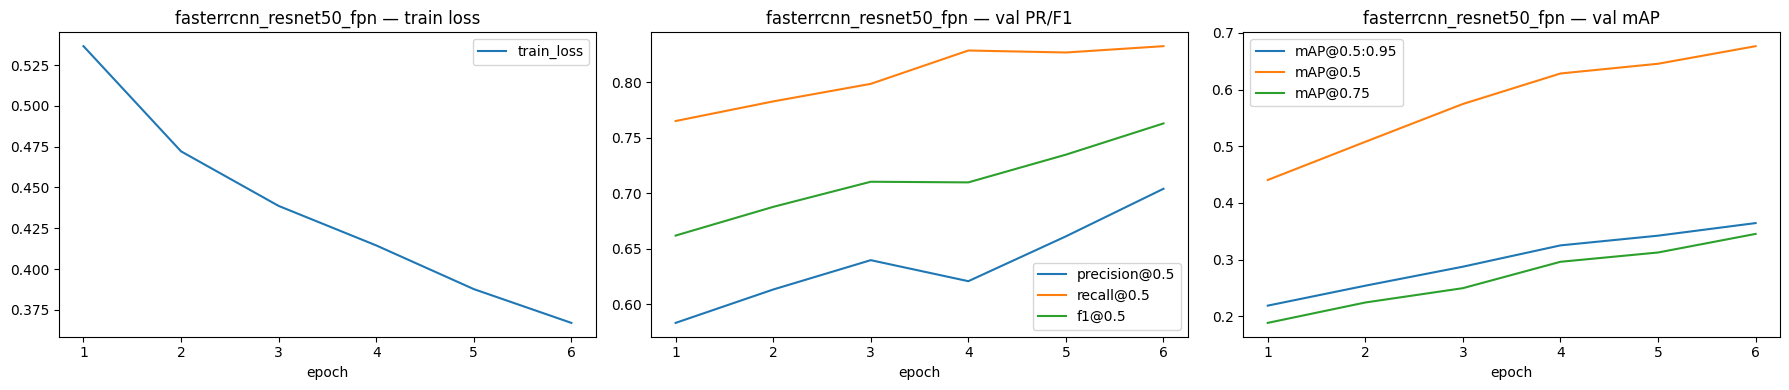


START EXPERIMENT: DET_FMMB | fasterrcnn_mobilenet_v3_large_fpn
Train this epoch - 25.0%
Train this epoch - 50.0%
Train this epoch - 75.0%
Train this epoch - 100.0%
[DET_FMMB] epoch 01/6 | train_loss=0.5959 | val_precision=0.6532 val_recall=0.6252 val_f1=0.6389 | val_map=0.1561 val_map50=0.3351 val_map75=0.1220 | time=1238.5s
Train this epoch - 25.0%
Train this epoch - 50.0%
Train this epoch - 75.0%
Train this epoch - 100.0%
[DET_FMMB] epoch 02/6 | train_loss=0.6166 | val_precision=0.6333 val_recall=0.6755 val_f1=0.6537 | val_map=0.1942 val_map50=0.4103 val_map75=0.1561 | time=1212.5s
Train this epoch - 25.0%
Train this epoch - 50.0%
Train this epoch - 75.0%
Train this epoch - 100.0%
[DET_FMMB] epoch 03/6 | train_loss=0.6312 | val_precision=0.6781 val_recall=0.6833 val_f1=0.6807 | val_map=0.2015 val_map50=0.4258 val_map75=0.1606 | time=1247.7s
Train this epoch - 25.0%
Train this epoch - 50.0%
Train this epoch - 75.0%
Train this epoch - 100.0%
[DET_FMMB] epoch 04/6 | train_loss=0.6454 |

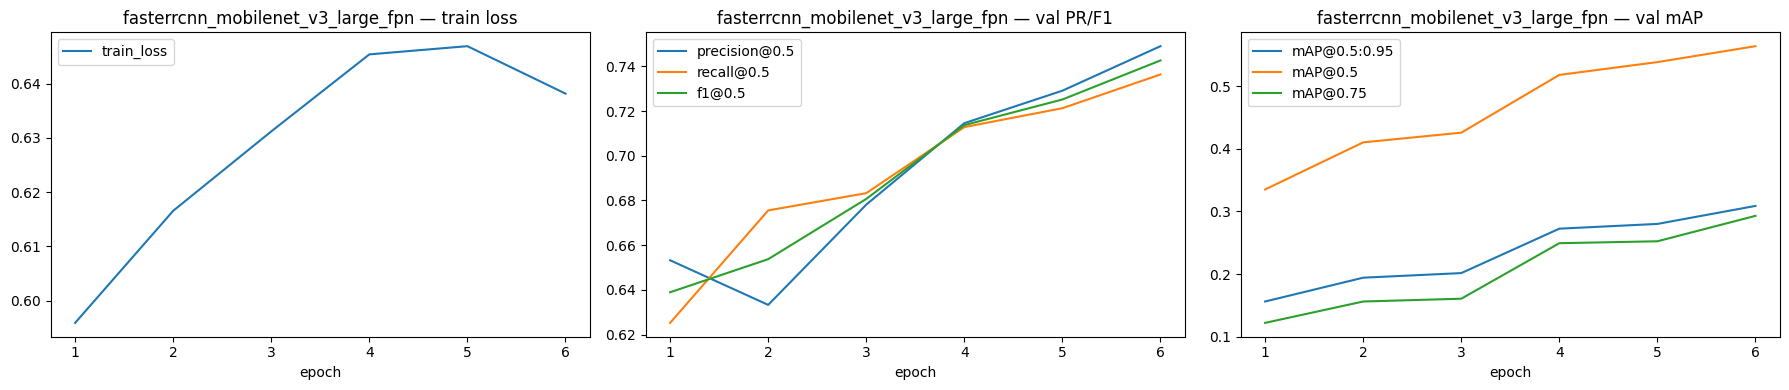


START EXPERIMENT: DET_RET50 | retinanet_resnet50_fpn
Train this epoch - 25.0%
Train this epoch - 50.0%
Train this epoch - 75.0%
Train this epoch - 100.0%
[DET_RET50] epoch 01/6 | train_loss=11.6709 | val_precision=0.6965 val_recall=0.6116 val_f1=0.6513 | val_map=0.1214 val_map50=0.2288 val_map75=0.1146 | time=2644.9s
Train this epoch - 25.0%
Train this epoch - 50.0%
Train this epoch - 75.0%
Train this epoch - 100.0%
[DET_RET50] epoch 02/6 | train_loss=0.4354 | val_precision=0.6922 val_recall=0.6808 val_f1=0.6864 | val_map=0.1781 val_map50=0.3395 val_map75=0.1645 | time=2545.9s
Train this epoch - 25.0%
Train this epoch - 50.0%
Train this epoch - 75.0%
Train this epoch - 100.0%
[DET_RET50] epoch 03/6 | train_loss=0.3979 | val_precision=0.6220 val_recall=0.7364 val_f1=0.6744 | val_map=0.2005 val_map50=0.3949 val_map75=0.1809 | time=2621.3s
Train this epoch - 25.0%
Train this epoch - 50.0%
Train this epoch - 75.0%
Train this epoch - 100.0%
[DET_RET50] epoch 04/6 | train_loss=0.3628 | val_

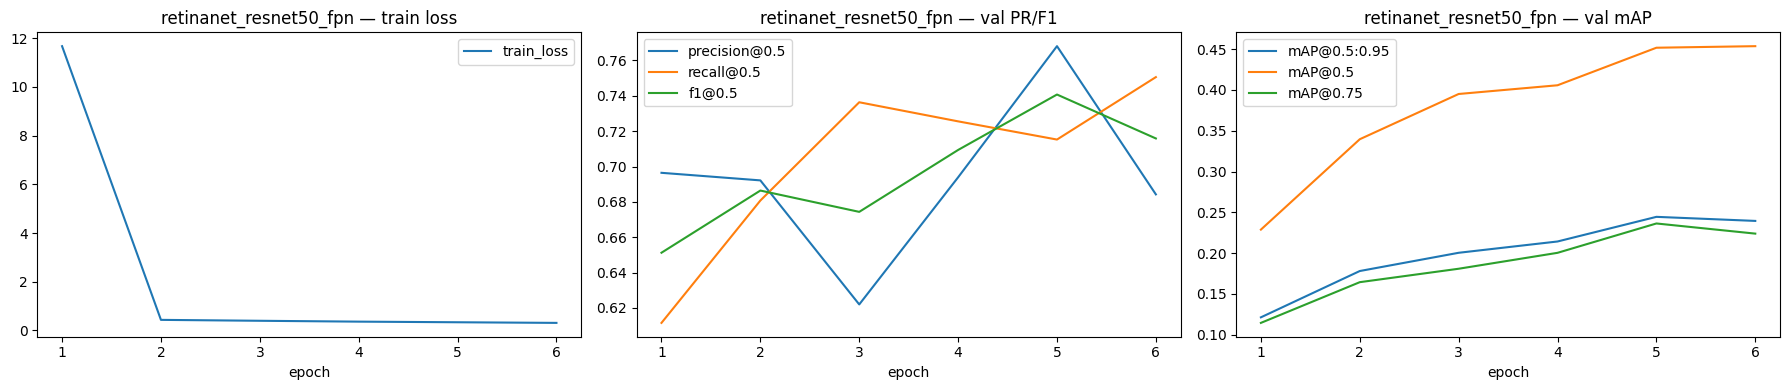

,experiment_id,model_name,epochs_requested,lr,weight_decay,score_threshold,val_precision@0.5,val_recall@0.5,val_f1@0.5,val_map,val_map@0.5,val_map@0.75,val_mar_1,val_mar_10,val_mar_100,tp,fp,fn,checkpoint
0,DET_FR50,fasterrcnn_resnet50_fpn,6,0.0001,0.0001,0.3,0.703980,0.832397,0.762822,0.364426,0.676483,0.345304,0.266865,0.442650,0.443948,32595,13706,6563,c:\Users\maxim\OneDrive\Документы\aie_course_r...
1,DET_FMMB,fasterrcnn_mobilenet_v3_large_fpn,6,0.0001,0.0001,0.3,0.749039,0.736376,0.742653,0.308818,0.563978,0.292947,0.218497,0.360677,0.361661,28835,9661,10323,c:\Users\maxim\OneDrive\Документы\aie_course_r...
2,DET_RET50,retinanet_resnet50_fpn,6,0.0001,0.0001,0.3,0.684267,0.750600,0.715900,0.239496,0.453508,0.223933,0.177382,0.295724,0.297063,29392,13562,9766,c:\Users\maxim\OneDrive\Документы\aie_course_r...


In [20]:
all_results = []
trained_models = {}
all_histories = {}

for cfg in experiment_plan:
    print("\n" + "=" * 100)
    print(f"START EXPERIMENT: {cfg.experiment_id} | {cfg.model_name}")
    print("=" * 100)

    model = build_detection_model(cfg.model_name, num_classes=num_classes).to(DEVICE)

    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(params, lr=cfg.lr, weight_decay=cfg.weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=1,
    )

    model, history, ckpt_path = fit_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        scheduler=scheduler,
        exp_name=cfg.experiment_id,
        epochs=cfg.epochs,
        patience=cfg.patience,
        score_threshold=cfg.score_threshold,
    )

    plot_history(
        history,
        title=cfg.model_name,
        save_path=FIGURES_DIR / f"{cfg.experiment_id}_curves.png",
    )

    val_metrics = evaluate_detection(model, val_loader, score_threshold=cfg.score_threshold, iou_thr=0.5)

    val_map_metrics = evaluate_detection_map(
        model,
        val_loader,
        score_threshold=cfg.score_threshold,
    )

    row = {
        "experiment_id": cfg.experiment_id,
        "model_name": cfg.model_name,
        "epochs_requested": cfg.epochs,
        "lr": cfg.lr,
        "weight_decay": cfg.weight_decay,
        "score_threshold": cfg.score_threshold,
        "val_precision@0.5": val_metrics["precision@0.5"],
        "val_recall@0.5": val_metrics["recall@0.5"],
        "val_f1@0.5": val_metrics["f1@0.5"],
        "val_map": val_map_metrics["map"],
        "val_map@0.5": val_map_metrics["map_50"],
        "val_map@0.75": val_map_metrics["map_75"],
        "val_mar_1": val_map_metrics["mar_1"],
        "val_mar_10": val_map_metrics["mar_10"],
        "val_mar_100": val_map_metrics["mar_100"],
        "tp": val_metrics["tp"],
        "fp": val_metrics["fp"],
        "fn": val_metrics["fn"],
        "checkpoint": str(ckpt_path),
    }
    all_results.append(row)
    trained_models[cfg.experiment_id] = model
    all_histories[cfg.experiment_id] = history

results_df = pd.DataFrame(all_results).sort_values("val_map@0.5", ascending=False).reset_index(drop=True)
results_df.to_csv(EXPERIMENTS_DIR / "detection_experiments.csv", index=False)
display(results_df)

## Сравнение результатов экспериментов

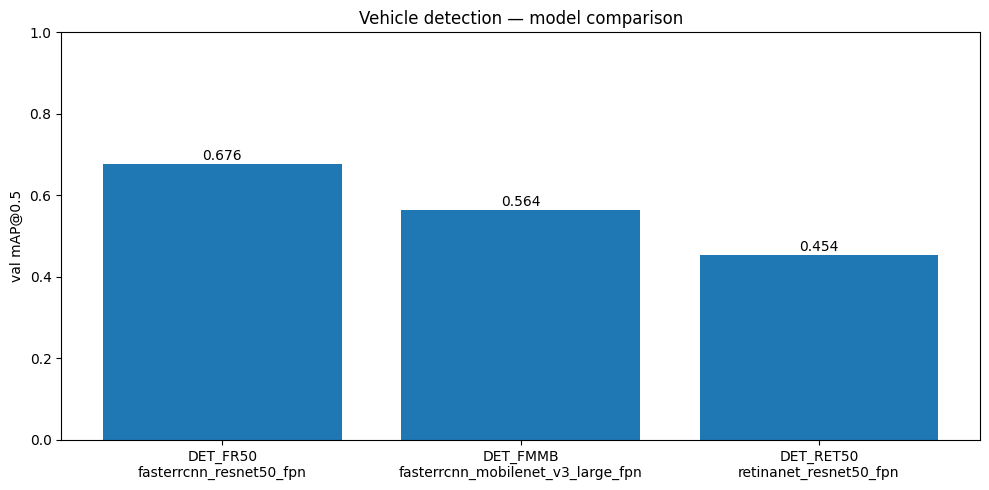

In [21]:
def compare_results_plot(df: pd.DataFrame, save_path: Path | None = None):
    names = df["experiment_id"] + "\n" + df["model_name"]

    plt.figure(figsize=(10, 5))
    plt.bar(names, df["val_map@0.5"])
    plt.ylim(0, 1)
    plt.ylabel("val mAP@0.5")
    plt.title("Vehicle detection — model comparison")
    for i, v in enumerate(df["val_map@0.5"]):
        plt.text(i, v + 0.01, f"{v:.3f}", ha="center")
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

compare_results_plot(results_df, FIGURES_DIR / "detection_model_comparison.png")

## Выбор лучшей модели

In [22]:
best_row = results_df.iloc[0]
best_experiment_id = best_row["experiment_id"]
best_model = trained_models[best_experiment_id]
print("Best experiment:")
display(best_row.to_frame().T)

Best experiment:


,experiment_id,model_name,epochs_requested,lr,weight_decay,score_threshold,val_precision@0.5,val_recall@0.5,val_f1@0.5,val_map,val_map@0.5,val_map@0.75,val_mar_1,val_mar_10,val_mar_100,tp,fp,fn,checkpoint
0,DET_FR50,fasterrcnn_resnet50_fpn,6,0.0001,0.0001,0.3,0.70398,0.832397,0.762822,0.364426,0.676483,0.345304,0.266865,0.44265,0.443948,32595,13706,6563,c:\Users\maxim\OneDrive\Документы\aie_course_r...


## Примеры предсказаний лучшей модели

In [23]:
@torch.no_grad()
def collect_val_predictions(model, dataset, score_threshold=0.3, max_images=None):
    model.eval()
    rows = []
    image_names = dataset.image_names[:max_images] if max_images is not None else dataset.image_names

    for idx, image_name in enumerate(image_names):
        image, target = dataset[idx]
        output = model([image.to(DEVICE)])[0]

        pred_boxes = output["boxes"].detach().cpu()
        pred_scores = output["scores"].detach().cpu()
        pred_labels = output["labels"].detach().cpu()

        keep = pred_scores >= score_threshold
        pred_boxes = pred_boxes[keep]
        pred_scores = pred_scores[keep]
        pred_labels = pred_labels[keep]

        rows.append({
            "image": image_name,
            "num_gt_boxes": len(target["boxes"]),
            "num_pred_boxes": len(pred_boxes),
            "mean_confidence": float(pred_scores.mean().item()) if len(pred_scores) > 0 else 0.0,
        })

    return pd.DataFrame(rows)

val_pred_summary = collect_val_predictions(best_model, val_dataset, score_threshold=float(best_row["score_threshold"]))
val_pred_summary.to_csv(PREDICTIONS_DIR / "best_model_val_summary.csv", index=False)
display(val_pred_summary.head())

,image,num_gt_boxes,num_pred_boxes,mean_confidence
0,1478019954186238236_jpg.rf.cbpP963e2sN7rHIZMJt...,6,11,0.719911
1,1478019957180061202_jpg.rf.YHpll4d5Wk2IKGKflOe...,9,12,0.738623
2,1478019960189614397_jpg.rf.579057110e268d1b10e...,6,21,0.588738
3,1478019960189614397_jpg.rf.Z5AUNjIXYDkZnux8iRd...,6,22,0.581704
4,1478019961182003465_jpg.rf.6f9292b69d3508b6ab3...,6,23,0.593496


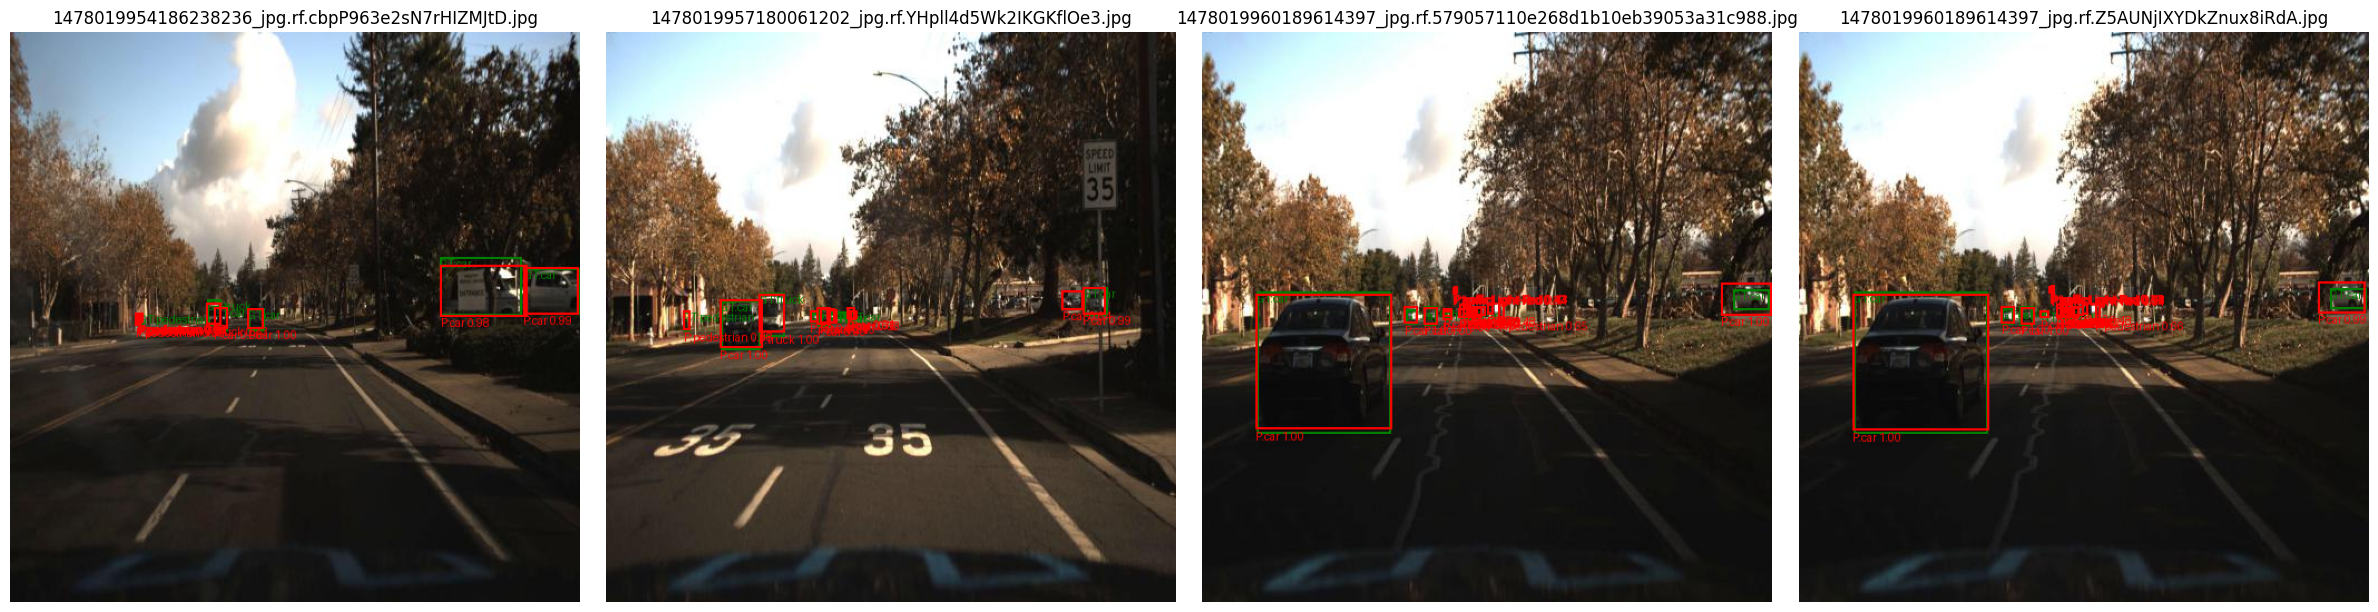

In [24]:
@torch.no_grad()
def show_predictions(dataset, model, id_to_label, score_threshold=0.3, n=4):
    n = min(n, len(dataset))
    plt.figure(figsize=(6 * n, 6))

    for i in range(n):
        image, target = dataset[i]
        output = model([image.to(DEVICE)])[0]

        pred_boxes = output["boxes"].detach().cpu()
        pred_scores = output["scores"].detach().cpu()
        pred_labels = output["labels"].detach().cpu()

        keep = pred_scores >= score_threshold
        pred_boxes = pred_boxes[keep]
        pred_scores = pred_scores[keep]
        pred_labels = pred_labels[keep]

        img = F.to_pil_image(image.cpu())
        img = img.copy()
        draw = ImageDraw.Draw(img)

        # GT in green
        for box, lbl in zip(target["boxes"].cpu(), target["labels"].cpu()):
            x1, y1, x2, y2 = box.tolist()
            draw.rectangle([x1, y1, x2, y2], outline="green", width=2)
            draw.text((x1, y1), f"GT:{id_to_label.get(int(lbl), int(lbl))}", fill="green")

        # Pred in red
        for box, score, lbl in zip(pred_boxes, pred_scores, pred_labels):
            x1, y1, x2, y2 = box.tolist()
            draw.rectangle([x1, y1, x2, y2], outline="red", width=2)
            draw.text((x1, y2), f"P:{id_to_label.get(int(lbl), int(lbl))} {float(score):.2f}", fill="red")

        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.title(target["image_name"])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_predictions(val_dataset, best_model, id_to_label, score_threshold=float(best_row["score_threshold"]), n=4)

## Сохранение артефактов

In [25]:
val_metrics_best = evaluate_detection(
    best_model,
    val_loader,
    score_threshold=float(best_row["score_threshold"]),
    iou_thr=0.5,
)
image_stats_df = val_metrics_best["image_stats"].copy()
image_stats_df["difficulty_score"] = image_stats_df["fp"] + image_stats_df["fn"]
image_stats_df = image_stats_df.sort_values(["difficulty_score", "fn", "fp"], ascending=False).reset_index(drop=True)
image_stats_df.to_csv(PREDICTIONS_DIR / "best_model_val_image_stats.csv", index=False)
display(image_stats_df.head(20))

,image_name,tp,fp,fn,difficulty_score
0,1478732085250968796_jpg.rf.830bae953355fd17f56...,8,22,3,25
1,1478897854426424817_jpg.rf.8789855175619365768...,20,16,8,24
2,1478897854426424817_jpg.rf.P6Aucc2TAb82UUlohgE...,19,14,9,23
3,1478899454038113102_jpg.rf.a29dbb80948718547fa...,15,15,8,23
4,1478899203812607459_jpg.rf.zh30XRPiFo4rYMau5S1...,14,16,7,23
5,1478897847570646127_jpg.rf.8c9f92453e8a64082b7...,20,20,3,23
6,1478898156067059403_jpg.rf.XHfVJUd3LShBmL43Udd...,6,20,3,23
7,1478901406707009151_jpg.rf.6WkiELBdIp78PXyqLlN...,17,12,10,22
8,1478897839574083845_jpg.rf.Hc0si7Ig1oz6PUAK8gy...,4,15,7,22
9,1478020452197377512_jpg.rf.43d1e945b562388db35...,15,16,6,22


In [26]:
best_config = {
    "task": "detection",
    "dataset": "Udacity Self Driving Car Dataset",
    "best_experiment_id": best_experiment_id,
    "best_model_name": best_row["model_name"],
    "num_classes_including_background": int(num_classes),
    "classes": classes,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "seed": SEED,
    "device": DEVICE,
    "use_amp": USE_AMP,
    "fast_mode": FAST_MODE,
    "annotations_csv": str(ANN_CSV),
    "images_dir": str(IMAGES_DIR),
    "best_val_precision@0.5": float(best_row["val_precision@0.5"]),
    "best_val_recall@0.5": float(best_row["val_recall@0.5"]),
    "best_val_f1@0.5": float(best_row["val_f1@0.5"]),
    "best_val_map": float(best_row["val_map"]),
    "best_val_map@0.5": float(best_row["val_map@0.5"]),
    "best_val_map@0.75": float(best_row["val_map@0.75"]),
    "best_val_mar_1": float(best_row["val_mar_1"]),
    "best_val_mar_10": float(best_row["val_mar_10"]),
    "best_val_mar_100": float(best_row["val_mar_100"]),
}

with open(EXPERIMENTS_DIR / "best_detection_model_config.json", "w", encoding="utf-8") as f:
    json.dump(best_config, f, ensure_ascii=False, indent=2)

torch.save(best_model.state_dict(), CHECKPOINTS_DIR / "best_detection_model.pt")
print(json.dumps(best_config, ensure_ascii=False, indent=2))

{
  "task": "detection",
  "dataset": "Udacity Self Driving Car Dataset",
  "best_experiment_id": "DET_FR50",
  "best_model_name": "fasterrcnn_resnet50_fpn",
  "num_classes_including_background": 12,
  "classes": [
    "biker",
    "car",
    "pedestrian",
    "trafficLight",
    "trafficLight-Green",
    "trafficLight-GreenLeft",
    "trafficLight-Red",
    "trafficLight-RedLeft",
    "trafficLight-Yellow",
    "trafficLight-YellowLeft",
    "truck"
  ],
  "image_size": 512,
  "batch_size": 4,
  "seed": 42,
  "device": "cuda",
  "use_amp": true,
  "fast_mode": false,
  "annotations_csv": "C:\\Users\\maxim\\OneDrive\\Документы\\aie_course_rep\\aie_course_rep\\project\\data\\processed\\detection\\annotations.csv",
  "images_dir": "C:\\Users\\maxim\\OneDrive\\Документы\\aie_course_rep\\aie_course_rep\\project\\data\\processed\\detection\\images",
  "best_val_precision@0.5": 0.7039804755835287,
  "best_val_recall@0.5": 0.832396955921949,
  "best_val_f1@0.5": 0.7628219330401123,
  "best_va

In [27]:
summary_df = results_df[[
    "experiment_id",
    "model_name",
    "val_precision@0.5",
    "val_recall@0.5",
    "val_f1@0.5",
    "val_map",
    "val_map@0.5",
    "val_map@0.75",
    "checkpoint",
]].copy()
summary_df.to_csv(EXPERIMENTS_DIR / "detection_summary_table.csv", index=False)
display(summary_df)

,experiment_id,model_name,val_precision@0.5,val_recall@0.5,val_f1@0.5,val_map,val_map@0.5,val_map@0.75,checkpoint
0,DET_FR50,fasterrcnn_resnet50_fpn,0.703980,0.832397,0.762822,0.364426,0.676483,0.345304,c:\Users\maxim\OneDrive\Документы\aie_course_r...
1,DET_FMMB,fasterrcnn_mobilenet_v3_large_fpn,0.749039,0.736376,0.742653,0.308818,0.563978,0.292947,c:\Users\maxim\OneDrive\Документы\aie_course_r...
2,DET_RET50,retinanet_resnet50_fpn,0.684267,0.750600,0.715900,0.239496,0.453508,0.223933,c:\Users\maxim\OneDrive\Документы\aie_course_r...


In [28]:
print("Готово.")
print("Сохранённые артефакты:")
print("-", EXPERIMENTS_DIR / "detection_experiments.csv")
print("-", EXPERIMENTS_DIR / "detection_summary_table.csv")
print("-", EXPERIMENTS_DIR / "best_detection_model_config.json")
print("-", CHECKPOINTS_DIR / "best_detection_model.pt")
print("-", PREDICTIONS_DIR / "best_model_val_summary.csv")
print("-", PREDICTIONS_DIR / "best_model_val_image_stats.csv")

Готово.
Сохранённые артефакты:
- c:\Users\maxim\OneDrive\Документы\aie_course_rep\aie_course_rep\project\artifacts\vehicle_detection\detection_experiments.csv
- c:\Users\maxim\OneDrive\Документы\aie_course_rep\aie_course_rep\project\artifacts\vehicle_detection\detection_summary_table.csv
- c:\Users\maxim\OneDrive\Документы\aie_course_rep\aie_course_rep\project\artifacts\vehicle_detection\best_detection_model_config.json
- c:\Users\maxim\OneDrive\Документы\aie_course_rep\aie_course_rep\project\artifacts\vehicle_detection\checkpoints\best_detection_model.pt
- c:\Users\maxim\OneDrive\Документы\aie_course_rep\aie_course_rep\project\artifacts\vehicle_detection\predictions\best_model_val_summary.csv
- c:\Users\maxim\OneDrive\Документы\aie_course_rep\aie_course_rep\project\artifacts\vehicle_detection\predictions\best_model_val_image_stats.csv


## Итоговый вывод

В ноутбуке были проведены основные эксперименты с detection-моделями torchvision для задачи детекции транспортных объектов.

По результатам сравнения лучшей моделью стала `Faster R-CNN ResNet50 FPN`, показавшая максимальное значение ключевой метрики `mAP@0.5`.

Финальная модель была сохранена в artifacts и далее будет использоваться в CLI inference и FastAPI-сервисе проекта.